#### 卡方分布的定义

设 \(Z_1, Z_2, \dots, Z_k\) 为独立的标准正态随机变量，那么卡方分布定义为

$$
X = \sum_{i=1}^{k} Z_i^2
$$

这种定义说明 \(X\) 是 \(k\) 个随机变量平方和的结果，而 \(k\) 被称作自由度。

#### 概率密度函数（PDF）

对于自由度为 $k 的卡方分布，其概率密度函数定义为：

$$
f(x; k) =
\begin{cases}
\displaystyle \frac{1}{2^{k/2} \Gamma(k/2)} x^{\frac{k}{2}-1} e^{-x/2}, & x > 0, \\
0, & x \le 0,
\end{cases}
$$

其中 $\Gamma(\cdot)$ 为伽马函数，其定义为：

$$
\Gamma(z) = \int_0^\infty t^{z-1} e^{-t}\, dt.
$$

#### 累积分布函数（CDF）

卡方分布的累积分布函数可表示为伽马分布的不完全伽马函数：

$$
F(x; k) = P(X \le x) = \frac{\gamma\left(\frac{k}{2}, \frac{x}{2}\right)}{\Gamma\left(\frac{k}{2}\right)},
$$

其中 $\gamma(s,x)$ 为下不完全伽马函数，定义为

$$
\gamma(s, x) = \int_0^x t^{s-1} e^{-t}\, dt.
$$

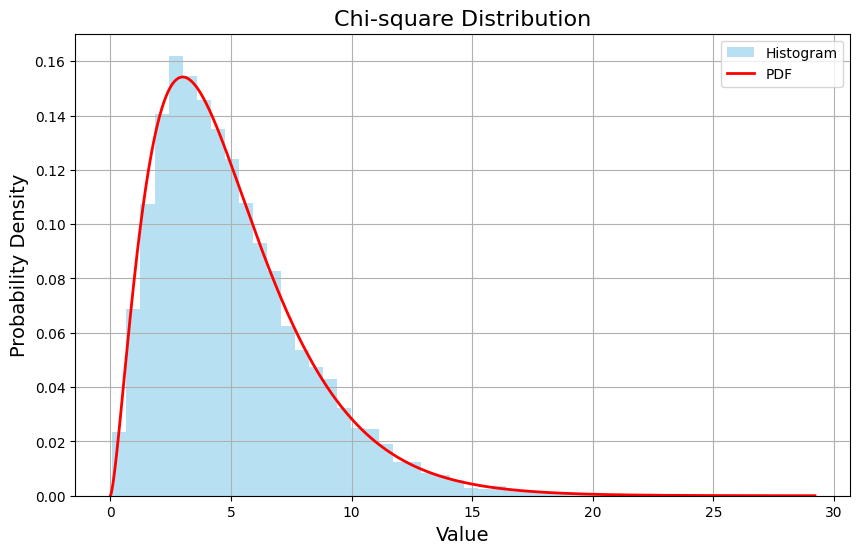

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 设置随机种子便于复现
np.random.seed(42)

# 定义卡方分布的自由度
df = 5

# 生成卡方分布数据
num_samples = 10000
data = np.random.chisquare(df, size=num_samples)

# 计算卡方分布的概率密度函数（PDF）用于绘图
x = np.linspace(0, np.max(data), 1000)
pdf = stats.chi2.pdf(x, df)

# 绘制直方图和理论概率密度曲线
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.6, color='skyblue', label="Histogram")
plt.plot(x, pdf, 'r-', lw=2, label="PDF")

# 设置标题和坐标轴标签
plt.title("Chi-square Distribution", fontsize=16)
plt.xlabel("Value", fontsize=14)
plt.ylabel("Probability Density", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 构造一个简单的文本数据集和标签
data = {
    "text": [
        "我喜欢这本书",
        "这本书非常好",
        "我不喜欢这本书",
        "这本书太差了",
        "非常精彩的故事",
        "情节非常无聊",
        "我强烈推荐这本书",
        "不推荐这本书",
        "故事情节引人入胜",
        "内容非常糟糕"
    ],
    "label": [1, 1, 0, 0, 1, 0, 1, 0, 1, 0]  # 1 表示正面，0 表示负面
}

df = pd.DataFrame(data)

# 对文本进行向量化，统计词频
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["text"])
y = df["label"]

# 使用卡方检验进行特征选择，选择排名前5的特征
chi2_selector = SelectKBest(chi2, k=5)
X_kbest = chi2_selector.fit_transform(X, y)

# 查看选择的特征名称
selected_indices = chi2_selector.get_support(indices=True)
selected_features = [vectorizer.get_feature_names_out()[i] for i in selected_indices]
print("Selected Features:", selected_features)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_kbest, y, test_size=0.3, random_state=42)

# 训练朴素贝叶斯分类器
clf = MultinomialNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Selected Features: ['我强烈推荐这本书', '故事情节引人入胜', '这本书太差了', '这本书非常好', '非常精彩的故事']
Accuracy: 0.3333333333333333
